# shor_15_simulation

This notebook starts the Stim simulation workstream for the simplified precompiled `a = 11`, `N = 15` Shor circuit. The active simulation object is a noisy three-logical-qubit Hadamard-test circuit, with each logical qubit represented by a `d = 3` triangular color-code instance from `color_code_stim`, equivalent to a Steane block. The default simulation uses uniform circuit-level noise `p = 1e-3`, idle-block syndrome extraction, and decoded Pauli-frame correction of the measured phase bit.


In [6]:
from pathlib import Path
import importlib
import sys
from pprint import pprint

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "Simulation" / "shor_simulation.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise ImportError("Could not locate Simulation/shor_simulation.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Simulation import shor_simulation
shor_simulation = importlib.reload(shor_simulation)


## Three Steane Blocks

Each block below is generated by `color_code_stim.ColorCode(d=3, circuit_type="tri")`. The local data-qubit, ancilla, and logical-observable supports come directly from the generated color-code patch; the global qubit ids are offset so the three blocks can live in one Stim circuit.


In [7]:
blocks = shor_simulation.generate_steane_code_instances()
block_summaries = shor_simulation.logical_block_summaries(blocks)
pprint(block_summaries)


[{'ancilla_qubits': 6,
  'circuit_type': 'tri',
  'data_qubits': 7,
  'distance': 3,
  'global_data_qids': (0, 1, 4, 7, 8, 9, 12),
  'global_logical_observable_qids': (0, 1, 4),
  'label': 'logical_0',
  'local_data_qids': (0, 1, 4, 7, 8, 9, 12),
  'local_logical_observable_qids': (0, 1, 4),
  'logical_index': 0,
  'patch_qubits': 13},
 {'ancilla_qubits': 6,
  'circuit_type': 'tri',
  'data_qubits': 7,
  'distance': 3,
  'global_data_qids': (13, 14, 17, 20, 21, 22, 25),
  'global_logical_observable_qids': (13, 14, 17),
  'label': 'logical_1',
  'local_data_qids': (0, 1, 4, 7, 8, 9, 12),
  'local_logical_observable_qids': (0, 1, 4),
  'logical_index': 1,
  'patch_qubits': 13},
 {'ancilla_qubits': 6,
  'circuit_type': 'tri',
  'data_qubits': 7,
  'distance': 3,
  'global_data_qids': (26, 27, 30, 33, 34, 35, 38),
  'global_logical_observable_qids': (26, 27, 30),
  'label': 'logical_2',
  'local_data_qids': (0, 1, 4, 7, 8, 9, 12),
  'local_logical_observable_qids': (0, 1, 4),
  'logical_in

## Encoded Precompiled Circuit

The bare reference circuit is `H` on the control qubit, two CNOTs from the control into the retained target qubits, a final `H`, and measurement of the control. The encoded circuit applies the same logical operations transversally, runs color-code syndrome extraction on idle logical blocks during control-only `H` layers, and runs one final syndrome round on all three blocks before logical readout.


In [8]:
bare_circuit = shor_simulation.build_unencoded_precompiled_shor_15_circuit()
encoded_circuit = shor_simulation.build_encoded_precompiled_shor_15_circuit(
    blocks,
    noise_rate=shor_simulation.DEFAULT_NOISE_RATE,
)

print("Bare circuit")
print(f"  qubits: {bare_circuit.num_qubits}")
print(f"  measurements: {bare_circuit.num_measurements}")
print(f"  observables: {bare_circuit.num_observables}")

print("\nEncoded circuit")
print(f"  qubits: {encoded_circuit.num_qubits}")
print(f"  measurements: {encoded_circuit.num_measurements}")
print(f"  observables: {encoded_circuit.num_observables}")
print(f"  detectors: {encoded_circuit.num_detectors}")
print(f"  default noise rate: {shor_simulation.DEFAULT_NOISE_RATE}")


Bare circuit
  qubits: 3
  measurements: 1
  observables: 1

Encoded circuit
  qubits: 39
  measurements: 67
  observables: 1
  detectors: 45
  default noise rate: 0.001


In [9]:
encoded_circuit_text = str(encoded_circuit)
print("\n".join(encoded_circuit_text.splitlines()[:120]))


QUBIT_COORDS(0, 0, 0) 0
QUBIT_COORDS(4, 0, 0) 1
QUBIT_COORDS(7, 0, 0) 2
QUBIT_COORDS(9, 0, 0) 3
QUBIT_COORDS(12, 0, 0) 4
QUBIT_COORDS(1, 1, 0) 5
QUBIT_COORDS(3, 1, 0) 6
QUBIT_COORDS(6, 1, 0) 7
QUBIT_COORDS(10, 1, 0) 8
QUBIT_COORDS(4, 2, 0) 9
QUBIT_COORDS(7, 2, 0) 10
QUBIT_COORDS(9, 2, 0) 11
QUBIT_COORDS(6, 3, 0) 12
QUBIT_COORDS(20, 0, 1) 13
QUBIT_COORDS(24, 0, 1) 14
QUBIT_COORDS(27, 0, 1) 15
QUBIT_COORDS(29, 0, 1) 16
QUBIT_COORDS(32, 0, 1) 17
QUBIT_COORDS(21, 1, 1) 18
QUBIT_COORDS(23, 1, 1) 19
QUBIT_COORDS(26, 1, 1) 20
QUBIT_COORDS(30, 1, 1) 21
QUBIT_COORDS(24, 2, 1) 22
QUBIT_COORDS(27, 2, 1) 23
QUBIT_COORDS(29, 2, 1) 24
QUBIT_COORDS(26, 3, 1) 25
QUBIT_COORDS(40, 0, 2) 26
QUBIT_COORDS(44, 0, 2) 27
QUBIT_COORDS(47, 0, 2) 28
QUBIT_COORDS(49, 0, 2) 29
QUBIT_COORDS(52, 0, 2) 30
QUBIT_COORDS(41, 1, 2) 31
QUBIT_COORDS(43, 1, 2) 32
QUBIT_COORDS(46, 1, 2) 33
QUBIT_COORDS(50, 1, 2) 34
QUBIT_COORDS(44, 2, 2) 35
QUBIT_COORDS(47, 2, 2) 36
QUBIT_COORDS(49, 2, 2) 37
QUBIT_COORDS(46, 3, 2) 38
R 0 1 4

## Logical Sampling

The sampled raw logical phase bit is corrected in software by XORing it with the color-code decoder's predicted logical observable flip. The decoded phase bit is then passed to the classical Shor post-processing below.


In [10]:
result = shor_simulation.run_precompiled_shor_15(
    shots=1024,
    seed=15,
    blocks=blocks,
    noise_rate=shor_simulation.DEFAULT_NOISE_RATE,
    decode=True,
)
pprint(result)


{'N': 15,
 'a': 11,
 'decode': True,
 'decoded_phase_bit_counts': {0: 518, 1: 506},
 'decoder_prediction_counts': {0: 886, 1: 138},
 'detectors': 45,
 'estimated_success_probability': 0.494140625,
 'factor_candidates_by_phase_bit': {0: None, 1: (3, 5)},
 'factor_counts': {None: 518, (3, 5): 506},
 'noise_rate': 0.001,
 'observables': 1,
 'phase_bit_counts': {0: 518, 1: 506},
 'raw_phase_bit_counts': {0: 502, 1: 522},
 'shots': 1024,
 'successful_factor_shots': 506}


## Result Visualization

The chart below separates the physical readout story from the decoded factoring story: raw versus decoded phase-bit counts, how often the decoder predicted a logical observable flip, and how many shots produced useful factors after decoding.


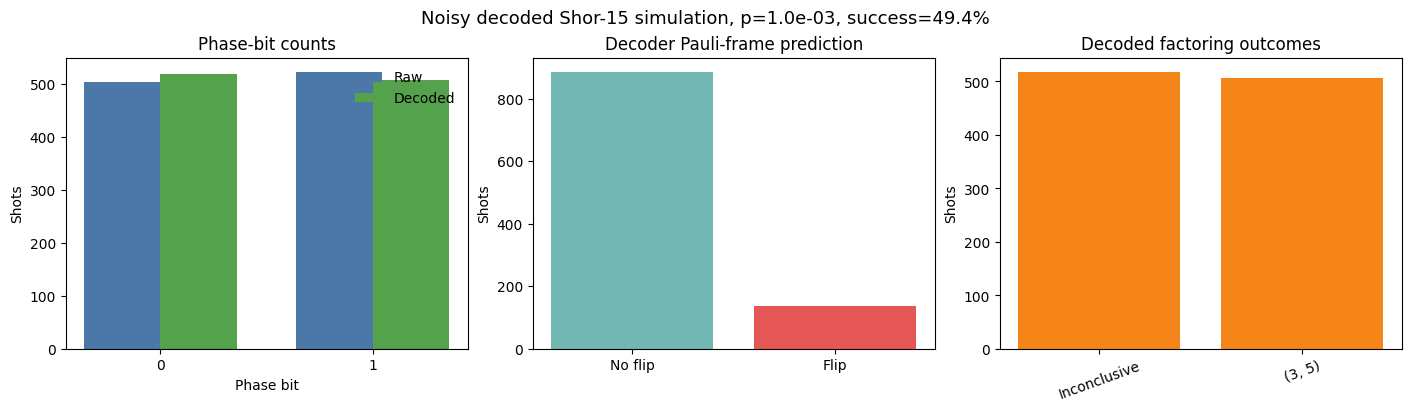

In [11]:
import matplotlib.pyplot as plt

raw_counts = result["raw_phase_bit_counts"]
decoded_counts = result["decoded_phase_bit_counts"]
decoder_counts = result["decoder_prediction_counts"]
factor_counts = result["factor_counts"]

phase_labels = ["0", "1"]
x_positions = range(len(phase_labels))
bar_width = 0.36

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

axes[0].bar(
    [x - bar_width / 2 for x in x_positions],
    [raw_counts.get(0, 0), raw_counts.get(1, 0)],
    width=bar_width,
    label="Raw",
    color="#4C78A8",
)
axes[0].bar(
    [x + bar_width / 2 for x in x_positions],
    [decoded_counts.get(0, 0), decoded_counts.get(1, 0)],
    width=bar_width,
    label="Decoded",
    color="#54A24B",
)
axes[0].set_title("Phase-bit counts")
axes[0].set_xticks(list(x_positions), phase_labels)
axes[0].set_xlabel("Phase bit")
axes[0].set_ylabel("Shots")
axes[0].legend(frameon=False)

axes[1].bar(
    ["No flip", "Flip"],
    [decoder_counts.get(0, 0), decoder_counts.get(1, 0)],
    color=["#72B7B2", "#E45756"],
)
axes[1].set_title("Decoder Pauli-frame prediction")
axes[1].set_ylabel("Shots")

factor_labels = []
factor_values = []
for outcome, count in factor_counts.items():
    factor_labels.append("Inconclusive" if outcome is None else str(outcome))
    factor_values.append(count)

axes[2].bar(factor_labels, factor_values, color="#F58518")
axes[2].set_title("Decoded factoring outcomes")
axes[2].set_ylabel("Shots")
axes[2].tick_params(axis="x", rotation=20)

success_probability = result["estimated_success_probability"]
fig.suptitle(
    f"Noisy decoded Shor-15 simulation, p={result['noise_rate']:.1e}, "
    f"success={success_probability:.1%}",
    fontsize=13,
)

plt.show()


## Why Decoded Phase Bit 1 Is the Useful Branch

The measured bit in this notebook is the decoded logical phase bit from the simplified one-bit Hadamard-test version of the precompiled `a = 11`, `N = 15` order-finding circuit. The raw physical readout is first corrected in software by the color-code decoder: the decoder predicts whether noise has flipped the logical observable, and the notebook forms

`decoded_phase_bit = raw_phase_bit XOR decoder_prediction`.

After that Pauli-frame correction, the decoded bit is interpreted by the classical Shor post-processing for this special reduced circuit. A decoded phase bit of `1` is the informative branch: it corresponds to the candidate order `r = 2`. For this instance,

`11^(r/2) = 11^1 = 11 mod 15`.

The standard Shor factor extraction step then computes the two gcds around this midpoint power:

`gcd(11 - 1, 15) = gcd(10, 15) = 5`

and

`gcd(11 + 1, 15) = gcd(12, 15) = 3`.

So decoded phase bit `1` gives the nontrivial factors `(3, 5)`. A decoded phase bit of `0` is not a failed factorization in the sense of producing wrong factors; it is simply inconclusive for this one-bit shortcut and would be handled by repeating the experiment.
